# Bitcoin Price Prediction Using LSTM and Random Forest  Models

## Introduction

Bitcoin is one of the most popular cryptocurrencies and its price changes frequently due to market volatility. Predicting Bitcoin prices has become an important task in financial analysis and data science. Machine Learning and Deep Learning models can analyze historical price data and identify patterns to forecast future trends.

In this project, historical Bitcoin data is collected using yfinance. Two models, LSTM and Random Forest, are trained using the closing price of Bitcoin. The models are evaluated using RMSE, MAE, and R² score, and future prices are predicted up to the year 2030.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

plt.style.use('seaborn')

## Load Bitcoin Data

In [3]:
import yfinance as yf

data = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")
btc = data[['Close']]
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,BTC-USD
Date,
2018-01-01,13657.200195
2018-01-02,14982.099609
2018-01-03,15201.000000
2018-01-04,15599.200195
2018-01-05,17429.500000


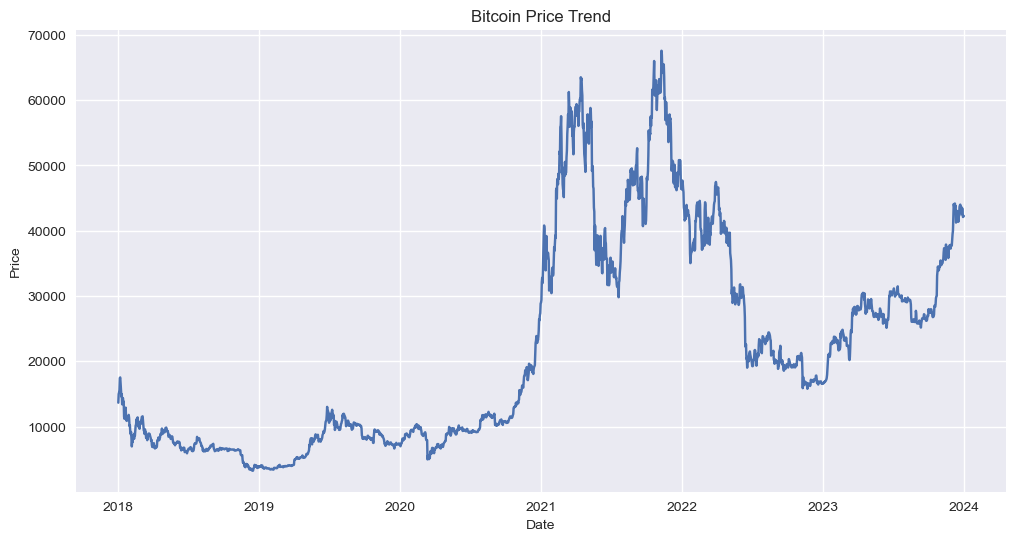

In [28]:
plt.figure(figsize=(12,6))
plt.plot(btc.index, btc['Close'])
plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Training Models 

## 1️⃣ Long Short-Term Memory (LSTM) 

## Normalize Data

In [4]:
# Normalize data between 0 and 1
scaler = MinMaxScaler()

btc_scaled = scaler.fit_transform(btc)

## Create Time Series Data

In [5]:
X = []
y = []

for i in range(60, len(btc_scaled)):
    X.append(btc_scaled[i-60:i])
    y.append(btc_scaled[i])

X = np.array(X)
y = np.array(y)

## Train-Test Split

In [6]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## Train LSTM Model

In [7]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, batch_size=32)



Epoch 1/10

54/54 [==============================] - 5s 33ms/step - loss: 0.0167
Epoch 2/10
54/54 [==============================] - 2s 32ms/step - loss: 0.0015
Epoch 3/10
54/54 [==============================] - 2s 32ms/step - loss: 0.0013
Epoch 4/10
54/54 [==============================] - 2s 33ms/step - loss: 0.0012
Epoch 5/10
54/54 [==============================] - 2s 34ms/step - loss: 0.0014
Epoch 6/10
54/54 [==============================] - 2s 38ms/step - loss: 0.0011
Epoch 7/10
54/54 [==============================] - 2s 34ms/step - loss: 9.9342e-04
Epoch 8/10
54/54 [==============================] - 2s 34ms/step - loss: 8.9739e-04
Epoch 9/10
54/54 [==============================] - 2s 33ms/step - loss: 8.4666e-04
Epoch 10/10
54/54 [==============================] - 2s 34ms/step - loss: 7.7760e-04


## LSTM Prediction 

In [8]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

14/14 [==============================] - 1s 10ms/step


##  LSTM Graph

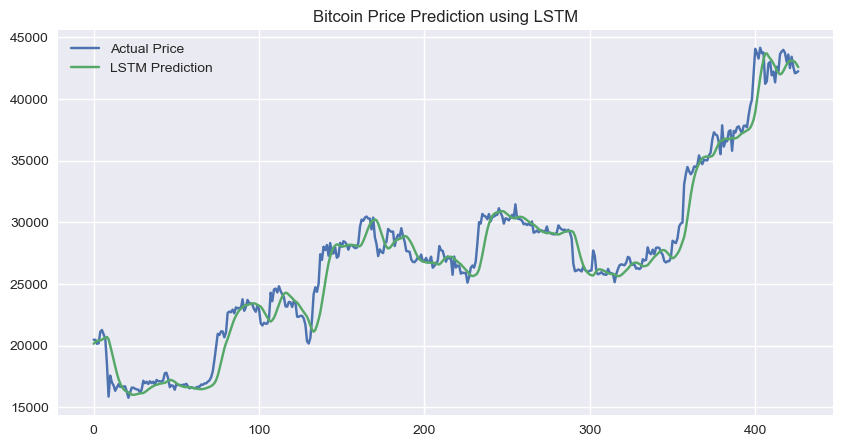

In [9]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(lstm_pred, label="LSTM Prediction")

plt.title("Bitcoin Price Prediction using LSTM")
plt.legend()

plt.show()

## LSTM Model Evaluation

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
r2_lstm = r2_score(y_test_actual, lstm_pred)

print("LSTM Model Evaluation")
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)
print("R2 Score:", r2_lstm)

LSTM Model Evaluation
RMSE: 1216.628493347489
MAE: 815.645537543911
R2 Score: 0.968143972285095


## 2️⃣ Random Forest Regressor Model

## Reshape Data for Random Forest

In [12]:
# Random Forest requires 2D input, so reshape the dataset.
X_train_rf = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_rf = X_test.reshape(X_test.shape[0], X_test.shape[1])

## Train Random Forest Model

In [13]:
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train_rf, y_train)

RandomForestRegressor()

## Random Forest Prediction

In [14]:
rf_pred = rf.predict(X_test_rf)

rf_pred = rf_pred.reshape(-1,1)

rf_pred = scaler.inverse_transform(rf_pred)

## Random Forest Graph

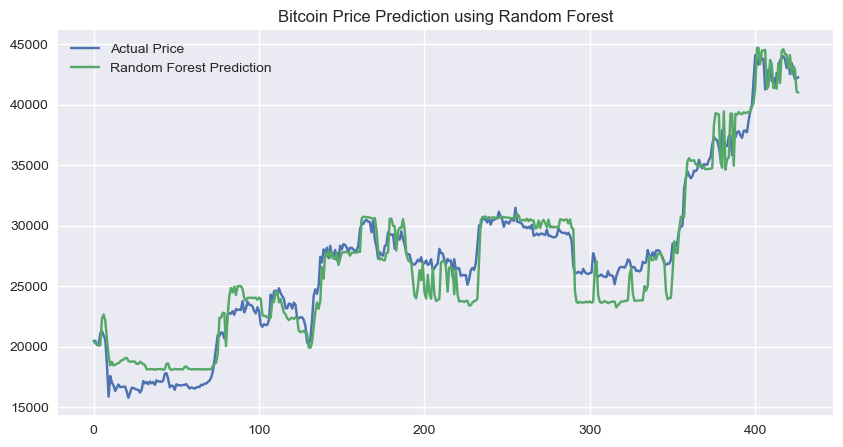

In [15]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(rf_pred, label="Random Forest Prediction")

plt.title("Bitcoin Price Prediction using Random Forest")
plt.legend()

plt.show()

## Random Forest Model Evaluation

In [16]:
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
mae_rf = mean_absolute_error(y_test_actual, rf_pred)
r2_rf = r2_score(y_test_actual, rf_pred)

print("Random Forest Model Evaluation")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

Random Forest Model Evaluation
RMSE: 1570.4509134929292
MAE: 1279.6126569818528
R2 Score: 0.9469207977864794


## MODEL COMPARISON

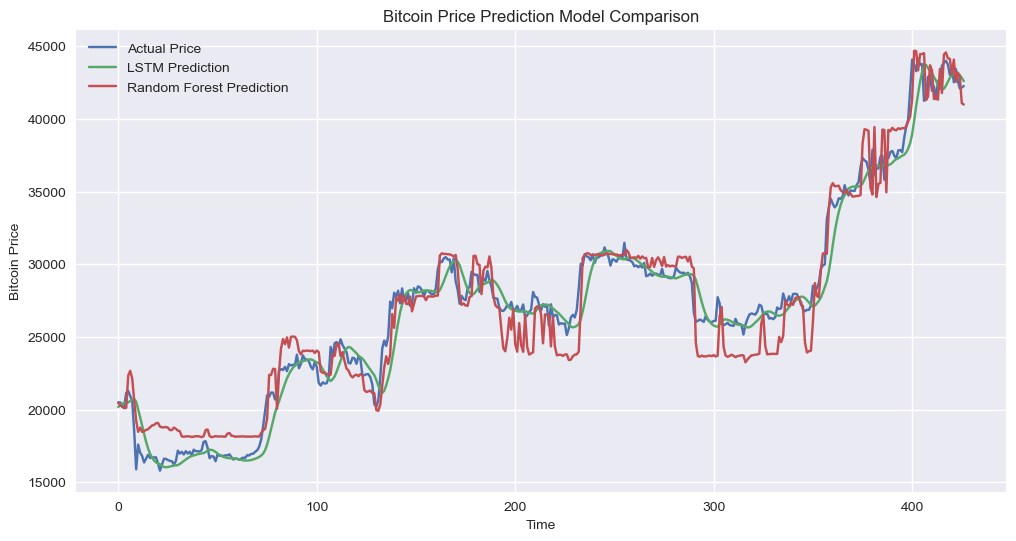

In [17]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.plot(rf_pred, label="Random Forest Prediction")

plt.title("Bitcoin Price Prediction Model Comparison")
plt.xlabel("Time")
plt.ylabel("Bitcoin Price")
plt.legend()

plt.show()

## Future Prediction Until 2030

## 1️⃣ Future Prediction Using LSTM

In [22]:
from datetime import timedelta
# Predict until 2030
future_days = 2200

last_60_days = btc_scaled[-60:]

future_predictions = []

current_input = last_60_days.reshape(1,60,1)

for i in range(future_days):

    pred_price = model.predict(current_input, verbose=0)

    future_predictions.append(pred_price[0][0])

    pred_price_reshaped = pred_price.reshape(1,1,1)

    current_input = np.concatenate((current_input[:,1:,:], pred_price_reshaped), axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))


# Create future dates

last_date = btc.index[-1]

future_dates = [last_date + timedelta(days=i) for i in range(1, future_days + 1)]


# Create dataframe
future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Price": future_predictions.flatten()
})

future_df.head(20)

,Date,Predicted Price
0,2024-01-01,42387.695312
1,2024-01-02,42215.679688
2,2024-01-03,42066.312500
3,2024-01-04,41931.136719
4,2024-01-05,41804.507812
5,2024-01-06,41682.816406
6,2024-01-07,41563.871094
7,2024-01-08,41446.406250
8,2024-01-09,41329.796875
9,2024-01-10,41213.710938


## Prediction Graph

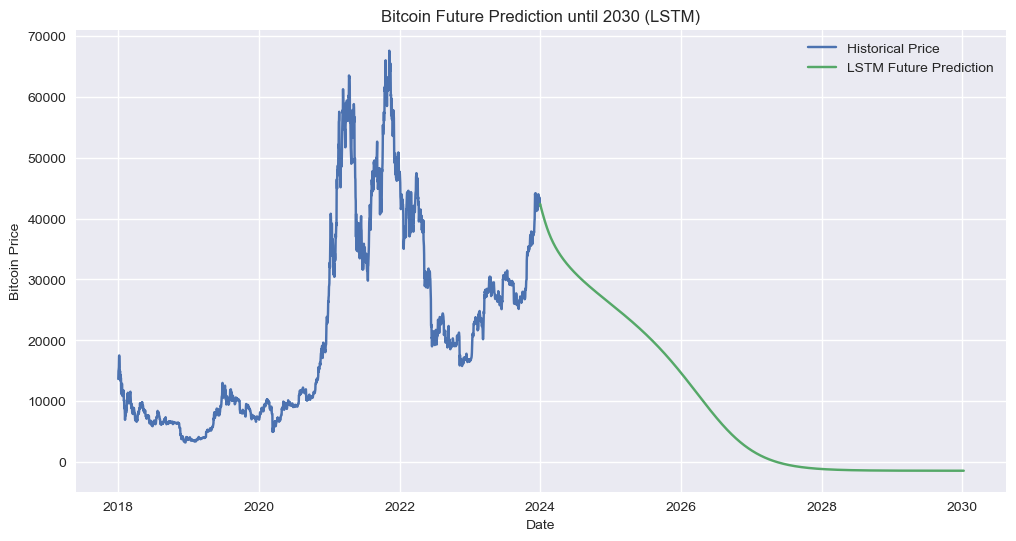

In [24]:
from datetime import timedelta

last_date = btc.index[-1]

future_dates = [last_date + timedelta(days=i) for i in range(1, future_days + 1)]

plt.figure(figsize=(12,6))

plt.plot(btc.index, btc['Close'], label="Historical Price")
plt.plot(future_dates, future_predictions, label="LSTM Future Prediction")

plt.title("Bitcoin Future Prediction until 2030 (LSTM)")
plt.xlabel("Date")
plt.ylabel("Bitcoin Price")

plt.legend()
plt.show()

## 2️⃣ Future Prediction Using Random Forest 

In [25]:
from datetime import timedelta
# Predict until 2030
future_days = 2200

future_rf = []

rf_sequence = btc_scaled[-60:].flatten()

for i in range(future_days):

    pred = rf.predict(rf_sequence.reshape(1,-1))

    future_rf.append(pred[0])

    rf_sequence = np.append(rf_sequence[1:], pred)


future_rf = np.array(future_rf).reshape(-1,1)

future_rf_prices = scaler.inverse_transform(future_rf)

last_date = btc.index[-1]

future_dates = [last_date + timedelta(days=i) for i in range(1, future_days + 1)]

future_rf_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Price": future_rf_prices.flatten()
})

future_rf_df

,Date,Predicted Price
0,2024-01-01,41414.449453
1,2024-01-02,40962.260898
2,2024-01-03,41097.557227
3,2024-01-04,41189.590469
4,2024-01-05,41055.595898
...,...,...
2195,2030-01-04,41656.144727
2196,2030-01-05,41656.144727
2197,2030-01-06,41656.144727
2198,2030-01-07,41656.144727


## Prediction Graph

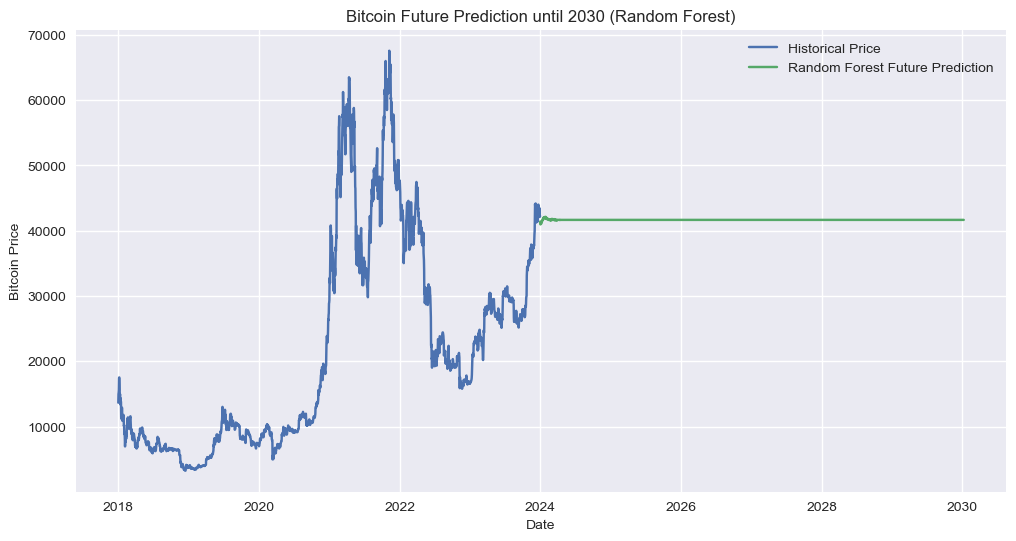

In [26]:
plt.figure(figsize=(12,6))

plt.plot(btc.index, btc['Close'], label="Historical Price")
plt.plot(future_dates, future_rf_prices, label="Random Forest Future Prediction")

plt.title("Bitcoin Future Prediction until 2030 (Random Forest)")
plt.xlabel("Date")
plt.ylabel("Bitcoin Price")

plt.legend()
plt.show()

## Comparison Graph

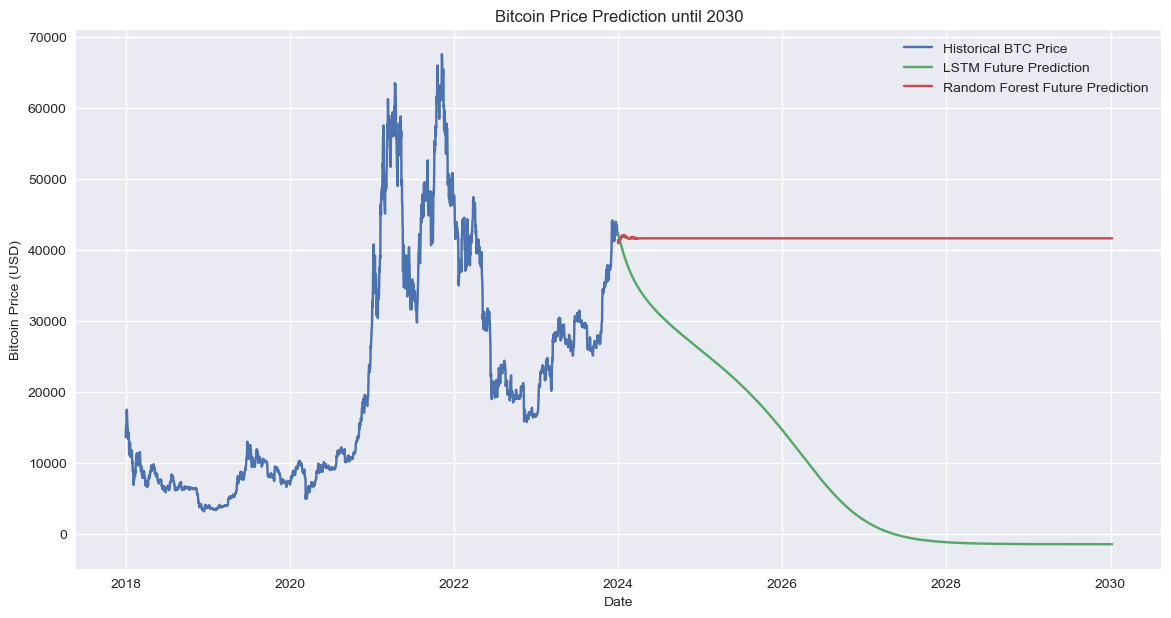

In [27]:
plt.figure(figsize=(14,7))

# Historical Bitcoin prices
plt.plot(btc.index, btc['Close'], label="Historical BTC Price")

# LSTM future prediction
plt.plot(future_dates, future_predictions, label="LSTM Future Prediction")

# Random Forest future prediction
plt.plot(future_dates, future_rf_prices, label="Random Forest Future Prediction")

plt.title("Bitcoin Price Prediction until 2030")
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")

plt.legend()
plt.grid(True)

plt.show()

## Conclusion

In this project, Bitcoin price prediction was performed using two different approaches: a deep learning model (LSTM) and a machine learning model (Random Forest Regressor). Historical Bitcoin price data was collected and processed to train both models.

The LSTM model was able to capture sequential patterns in the time-series data, making it more suitable for predicting trends over time. The Random Forest model also produced reasonable predictions but does not naturally handle time dependency like LSTM.

Model performance was evaluated using metrics such as Root Mean Square Error (RMSE), Mean Absolute Error (MAE), and R² Score. The results show how different models perform on the same dataset.

Finally, both models were used to generate future Bitcoin price predictions up to the year 2030, and the results were visualized using graphs for better understanding.

This project demonstrates how machine learning and deep learning techniques can be applied to cryptocurrency market analysis and financial forecasting.